In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

import matplotlib.pyplot as plt
import celldega as dega
import numpy as np
import scanpy as sc
import squidpy as sq
import pandas as pd
import seaborn as sns
import geopandas as gpd
from anndata import AnnData
from mudata import MuData
import muon as mu
from celldega.pre import _to_coords
import warnings
warnings.filterwarnings("ignore")

env: ANYWIDGET_HMR=1


In [2]:
# dataset_name = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
dataset_name = 'Xenium_V1_human_Pancreas_FFPE_outs'
tech = 'Xenium'
DATA_DIR = f'data/raw'
data_dir = f'{DATA_DIR}/{dataset_name}'
path_landscape_files = f'data/landscape_files/{dataset_name}'

# Load h5ad file
adata_raw = sc.read_h5ad(f'{data_dir}.h5ad')
adata_raw.obs.set_index('cell_id', inplace=True)

# Create gdf for a certain type of nbhd

In [3]:
nbhd_type = 'HEX'  # Choose from 'ALPH', 'HEX', 'SKTCH', 'GRAD'

if nbhd_type == 'HEX':
    gdf_cell = dega.nbhd._get_gdf_cell(adata_raw)
    gdf_nbhd = dega.nbhd.generate_hex_grid(gdf_cell, radius=50) # fedault=50

elif nbhd_type == 'ALPH':
    alphas_list = range(30, 60, 5)
    df_cell = dega.nbhd._get_df_cell(adata_raw)
    gdf_alpha = dega.nbhd.alpha_shape_cell_clusters(df_cell, cat='cluster', alphas=alphas_list)
    gdf_nbhd = gdf_alpha.loc[gdf_alpha['inv_alpha']==35]

elif nbhd_type == 'SKTCH':
    gdf_nbhd = gpd.read_parquet(f'{path_landscape_files}/spatial_regions/sketched_regions_micron.parquet')
    gdf_nbhd['name'] = gdf_nbhd['roi']

elif nbhd_type == 'GRAD':
    gdf_cell = dega.nbhd._get_gdf_cell(adata_raw)
    gdf_micron = gpd.read_parquet(f'{path_landscape_files}/spatial_regions/sketched_regions_micron.parquet')
    gdf_roi = gdf_micron.loc[gdf_micron['roi'] == 'region_1']
    gdf_nbhd = dega.nbhd.calc_grad_nbhd_from_roi(gdf_roi, gdf_cell, 200)
    gdf_nbhd['name'] = gdf_nbhd['band']

display(gdf_nbhd.head())

,name,geometry
0,hex_0,"POLYGON ((1047.78951 33.96586, 1004.48824 58.9..."
1,hex_1,"POLYGON ((1134.39205 33.96586, 1091.09078 58.9..."
2,hex_2,"POLYGON ((1220.99459 33.96586, 1177.69332 58.9..."
3,hex_3,"POLYGON ((1307.59713 33.96586, 1264.29586 58.9..."
4,hex_4,"POLYGON ((1394.19967 33.96586, 1350.89840 58.9..."


# Create NBHD instance and attached derived matrices

In [4]:
# Create NBHD instance
nbhd = dega.nbhd.NBHD(
    gdf_nbhd,
    nbhd_type=nbhd_type,
    adata=adata_raw,
    data_dir=data_dir,
    path_landscape_files=path_landscape_files,
    source='X cells',
    name='X cell alpha shapes'
    )

# Calculate and attach derived data
keys = [
    'NBG-CD', # nbhd by gene expression - cell derived
    'NBG-CF', # nbhd by gene expression - cell-free derived
    'NBG-LCD',# nbhd by gene expression - leiden cluster derived
    'NBP',   # nbhd by polulation (abs or pct)
    'NBM',   # nbhd by metadata
    'NBI',   # nbhd by image intensity (mean, median, std)
        ]

[nbhd.set_derived(key) for key in keys] # regular ones
nbhd.set_derived('NBN-O' if nbhd_type == 'ALPH' else 'NBN-B') #NBN

nbhd.summary()

Calculating NBG-CD
NBG-CD is derived and attached to nbhd
Calculating NBG-CF
NBG-CF is derived and attached to nbhd
Calculating NBG-LCD
NBG-LCD is derived and attached to nbhd
Calculating NBP
NBP is derived and attached to nbhd
Calculating NBM


<tifffile.TiffFile 'morphology_focus_0000.ome.tif'> OME series cannot read multi-file pyramids


NBM is derived and attached to nbhd
NBI is derived and attached to nbhd
Calculating neighborhood bordering
Calculating NBN-B
NBN-B is derived and attached to nbhd


{'name': 'X cell alpha shapes',
 'type': 'HEX',
 'n_regions': 3065,
 'derived': {'NBI': (3065, 12),
  'NBG-CF': (3065, 541),
  'NBG-CD': (3065, 377),
  'NBG-LCD': {'0': (3065, 377),
   '1': (3065, 377),
   '10': (3065, 377),
   '2': (3065, 377),
   '3': (3065, 377),
   '4': (3065, 377),
   '5': (3065, 377),
   '6': (3065, 377),
   '7': (3065, 377),
   '8': (3065, 377),
   '9': (3065, 377)},
  'NBP': {'abs': (3065, 11), 'pct': (3065, 11)},
  'NBN-O': None,
  'NBN-B': (5285, 2),
  'NBM': (3065, 8)},
 'meta': {}}

# Retrieve data and plot

### NBG

NBG-CD data example


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,TRAC,TREM2,TSPAN19,UBE2C,UMOD,UPK3B,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 33.96586, 1004.48824 58.9...",0.000000,0.0,0.0,1.352402,0.000000,0.0000,0.084977,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.636131,0.0,0.000000,0.258784
1,hex_1,"POLYGON ((1134.39205 33.96586, 1091.09078 58.9...",0.031594,0.0,0.0,0.216463,0.312521,0.0225,0.077016,0.010964,...,0.022742,0.055474,0.0,0.266640,0.0,0.0,0.752364,0.0,0.152725,0.000000
2,hex_2,"POLYGON ((1220.99459 33.96586, 1177.69332 58.9...",0.000000,0.0,0.0,0.000000,0.510874,0.0000,0.000000,0.000000,...,0.042488,0.000000,0.0,0.151858,0.0,0.0,0.318016,0.0,0.000000,0.000000


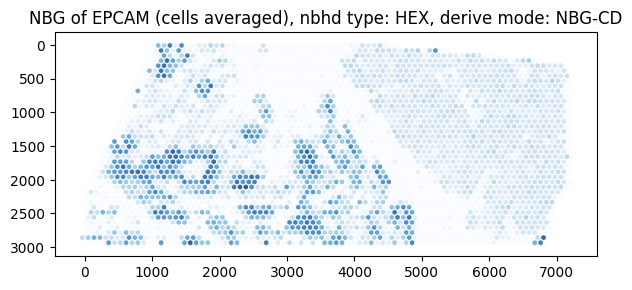

NBG-LCD data example, cluster:1


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,TRAC,TREM2,TSPAN19,UBE2C,UMOD,UPK3B,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 33.96586, 1004.48824 58.9...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,hex_1,"POLYGON ((1134.39205 33.96586, 1091.09078 58.9...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,hex_2,"POLYGON ((1220.99459 33.96586, 1177.69332 58.9...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


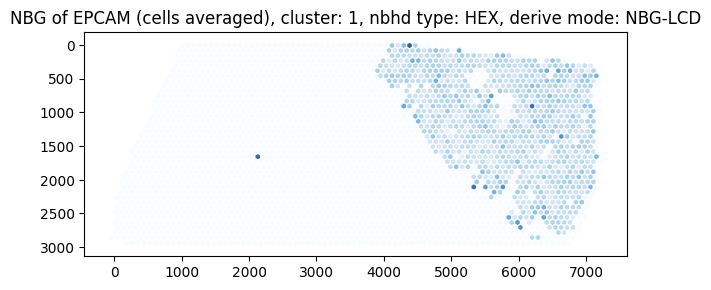

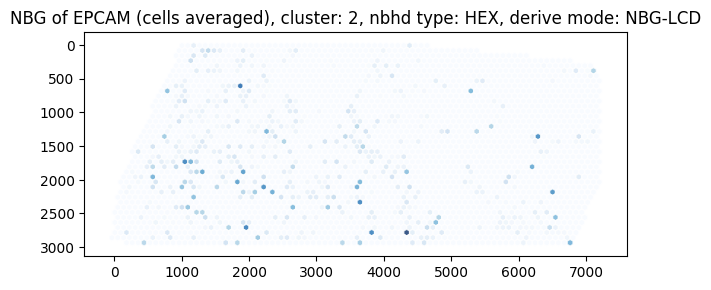

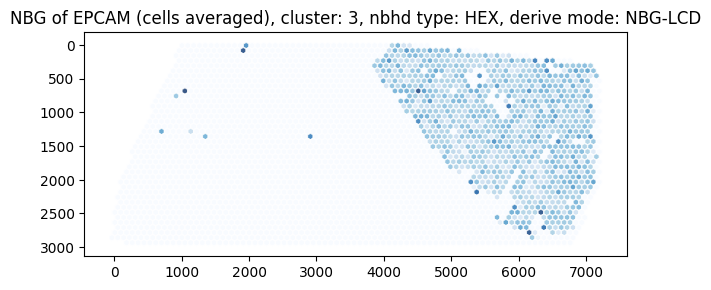

NBG-CF data example


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,UnassignedCodeword_0494,UnassignedCodeword_0495,UnassignedCodeword_0496,UnassignedCodeword_0497,UnassignedCodeword_0498,UnassignedCodeword_0499,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 33.96586, 1004.48824 58.9...",0,0,0,22,0,0,2,0,...,0,0,0,0,0,0,21,0,0,10
1,hex_1,"POLYGON ((1134.39205 33.96586, 1091.09078 58.9...",1,0,0,23,41,2,2,1,...,0,0,0,0,0,0,59,1,10,0
2,hex_2,"POLYGON ((1220.99459 33.96586, 1177.69332 58.9...",0,0,0,0,18,0,0,0,...,0,0,0,0,0,0,18,1,0,1


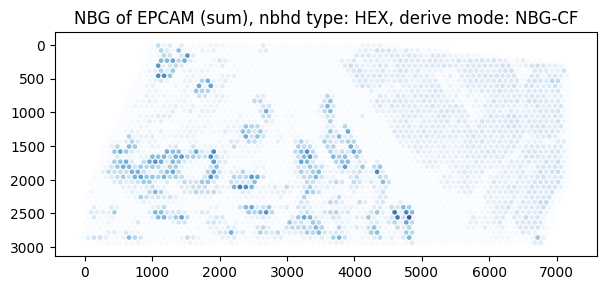

In [5]:
gene = 'EPCAM'
figsize = (7,3)
default_camp = 'Blues'

# Retrieve and visualize
gdf_nbg_cd = nbhd.get_derived('NBG-CD')
print ('NBG-CD data example')
display(gdf_nbg_cd.head(3))

fig, ax = plt.subplots(figsize=figsize)                           
gdf_nbg_cd.plot(gene, ax=ax, aspect=1, cmap=default_camp, edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} (cells averaged), nbhd type: {nbhd_type}, derive mode: NBG-CD')
ax.invert_yaxis()
plt.show()

# Retrieve and visualize
clusters = ['1','2','3']
for cluster in clusters:
    gdf_nbg_lcd = nbhd.get_derived('NBG-LCD', cluster)

    if cluster == '1':
        print (f'NBG-LCD data example, cluster:{cluster}')
        display(gdf_nbg_lcd.head(3))       

    fig, ax = plt.subplots(figsize=figsize)                           
    gdf_nbg_lcd.plot(gene, ax=ax, aspect=1, cmap=default_camp, edgecolor='white', alpha=0.8)
    ax.set_title(f'NBG of {gene} (cells averaged), cluster: {cluster}, nbhd type: {nbhd_type}, derive mode: NBG-LCD')       
    ax.invert_yaxis()
    plt.show()


# Retrieve and visualize
gdf_nbg_cf = nbhd.get_derived('NBG-CF')

print ('NBG-CF data example')
display(gdf_nbg_cf.head(3))

fig, ax = plt.subplots(figsize=figsize)                           
gdf_nbg_cf.plot(gene, ax=ax, aspect=1, cmap=default_camp, edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} (sum), nbhd type: {nbhd_type}, derive mode: NBG-CF')
ax.invert_yaxis()
plt.show()


### NBP

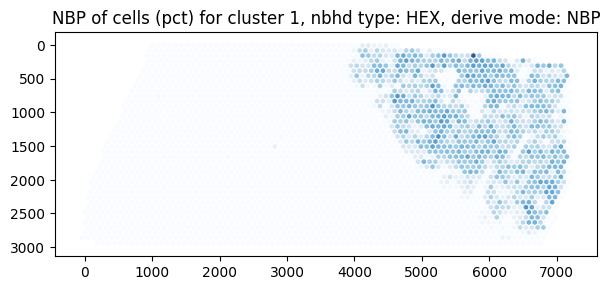

In [6]:
# Retrieve and visualize
sub_key = 'pct'
cluster_name = '1'

gdf_nbp = nbhd.get_derived('NBP', sub_key)

fig, ax = plt.subplots(figsize=figsize)                           
gdf_nbp.plot(cluster_name, ax=ax, aspect=1, cmap=default_camp, edgecolor='white', alpha=0.8)
ax.set_title(f'NBP of cells ({sub_key}) for cluster {cluster_name}, nbhd type: {nbhd_type}, derive mode: NBP')
ax.invert_yaxis()
plt.show()

### NBM (metadata)

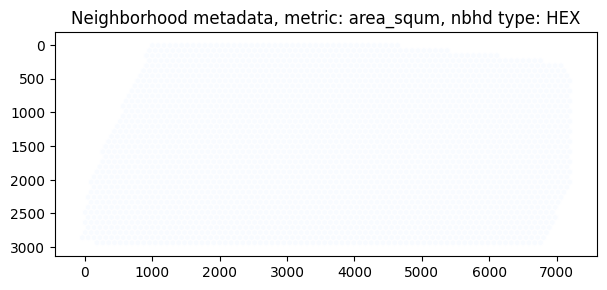

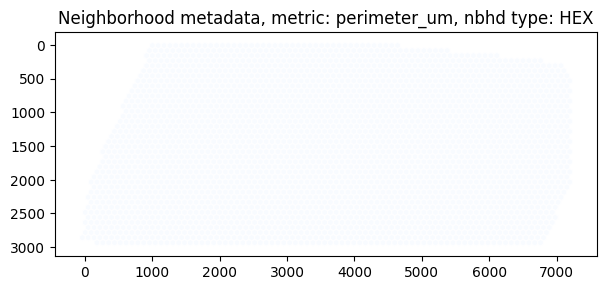

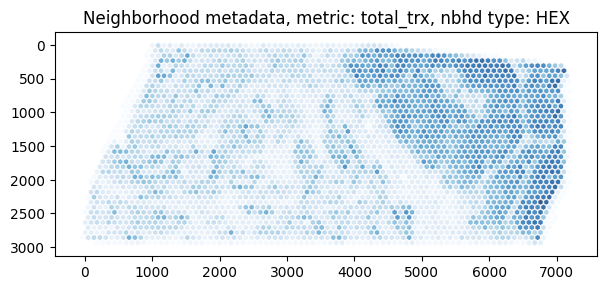

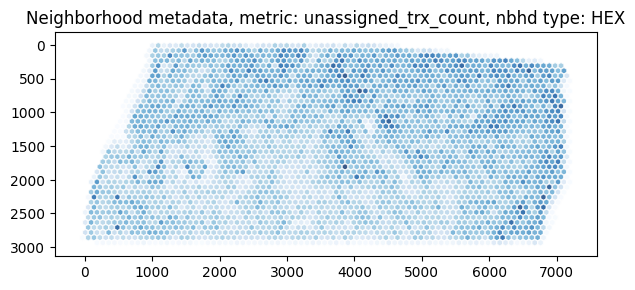

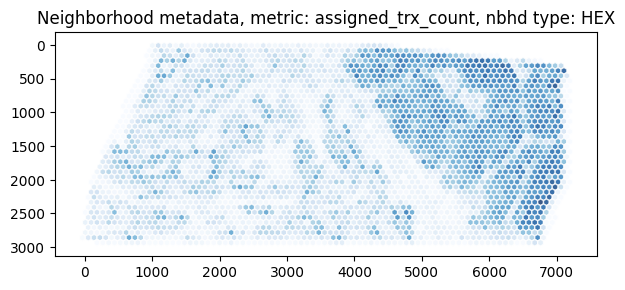

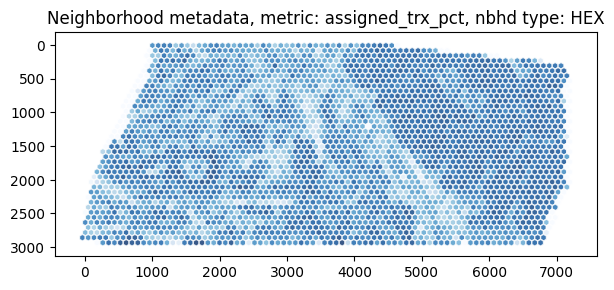

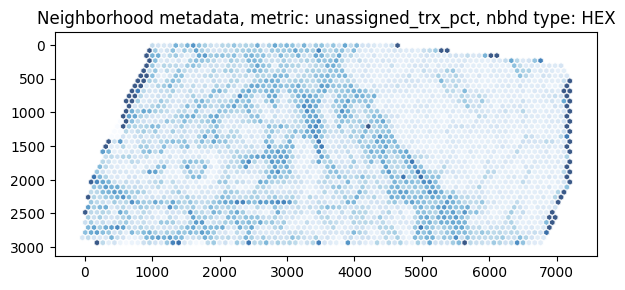

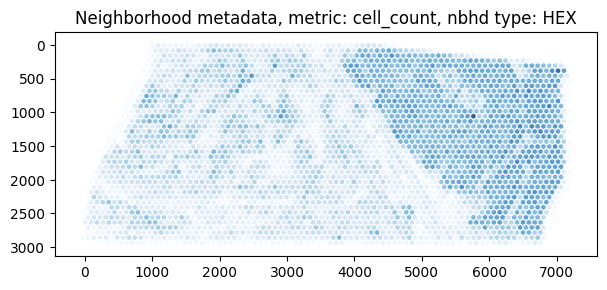

In [7]:
meta = nbhd.get_derived('NBM')

for metric in meta.select_dtypes(include='number').columns:
    fig, ax = plt.subplots(figsize=figsize)                           
    meta.plot(metric, ax=ax, aspect=1, cmap=default_camp, edgecolor='white', alpha=0.8)
    ax.set_title(f'Neighborhood metadata, metric: {metric}, nbhd type: {nbhd_type}')
    ax.invert_yaxis()
    plt.show()

### NBI (neighborhood by image)
This is more useful when derived from imaging-based spatial proteomics data. Here we just use the stainnings from Xenium (DAPI, Bound, RNA, Protein) as an example.

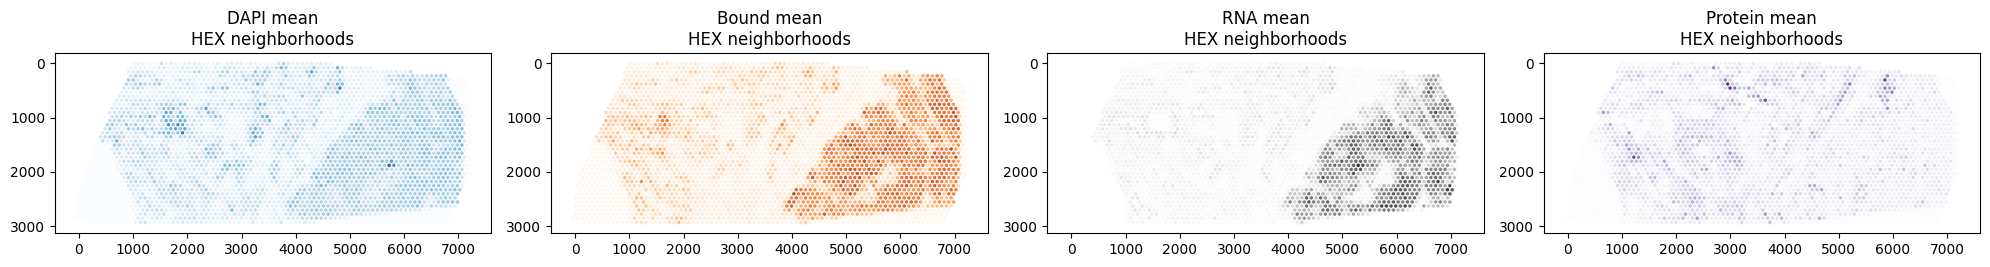

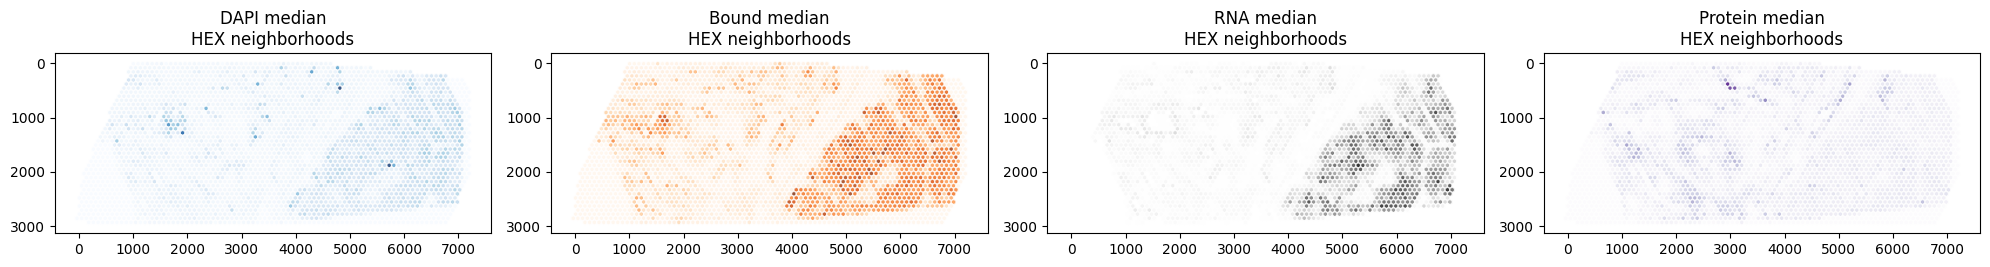

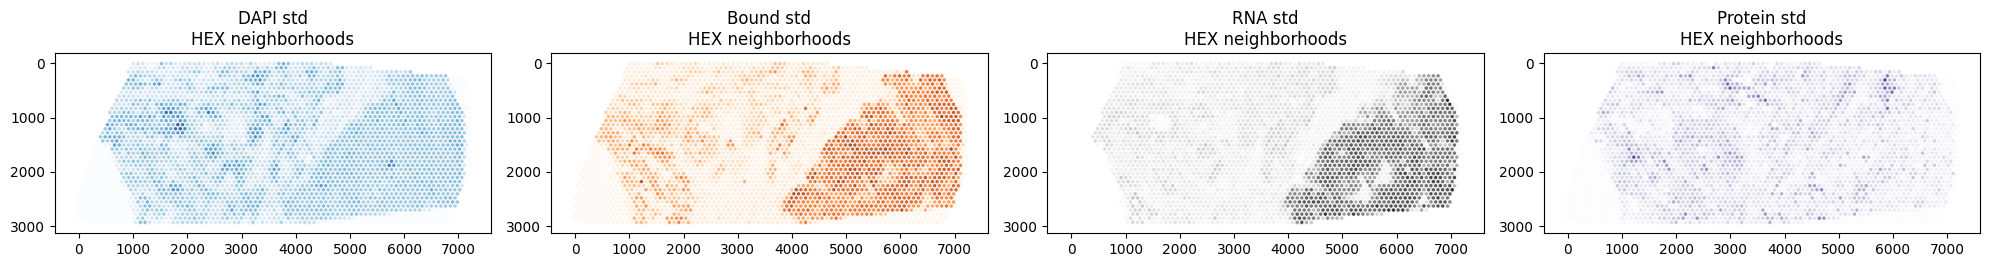

In [8]:
if 'NBI' not in keys:
    pass

else:
    # Retrieve and visualize  
    gdf_nbi = nbhd.get_derived('NBI')
    # Retrieve and visualize
    metrics = ['mean','median','std']

    for metric in metrics:
  
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,7))
        
        # DAPI plot (leftmost)
        gdf_nbi.plot(f'dapi_{metric}', ax=ax1, aspect=1, cmap='Blues', edgecolor='white', alpha=0.8)
        ax1.set_title(f'DAPI {metric}\n{nbhd_type} neighborhoods')
        ax1.invert_yaxis()
        
        # Bound plot (second)
        gdf_nbi.plot(f'bound_{metric}', ax=ax2, aspect=1, cmap='Oranges', edgecolor='white', alpha=0.8)
        ax2.set_title(f'Bound {metric}\n{nbhd_type} neighborhoods')
        ax2.invert_yaxis()
        
        # RNA plot (third)
        gdf_nbi.plot(f'rna_{metric}', ax=ax3, aspect=1, cmap='Greys', edgecolor='white', alpha=0.8)
        ax3.set_title(f'RNA {metric}\n{nbhd_type} neighborhoods')
        ax3.invert_yaxis()
        
        # Protein plot (rightmost)
        gdf_nbi.plot(f'prot_{metric}', ax=ax4, aspect=1, cmap='Purples', edgecolor='white', alpha=0.8)
        ax4.set_title(f'Protein {metric}\n{nbhd_type} neighborhoods')
        ax4.invert_yaxis()
        
        plt.tight_layout()
        plt.show()

# Neighborhood by neighborhood

calculating neighborhood overlap
Calculating NBN-O
(49, 4)


,nbhd_1,nbhd_2,overlap_area,geometry
0,0_35,2_35,4679966.74,"MULTIPOLYGON (((313.206 2859.320, 323.670 2863..."
1,0_35,1_35,34152.73,"MULTIPOLYGON (((6632.260 2752.140, 6628.363 27..."
2,0_35,3_35,86889.75,"MULTIPOLYGON (((6696.800 2740.560, 6691.240 27..."
3,0_35,5_35,297301.74,"MULTIPOLYGON (((6716.072 2741.804, 6702.230 27..."
4,0_35,6_35,27883.91,"MULTIPOLYGON (((6435.489 2778.942, 6458.940 27..."


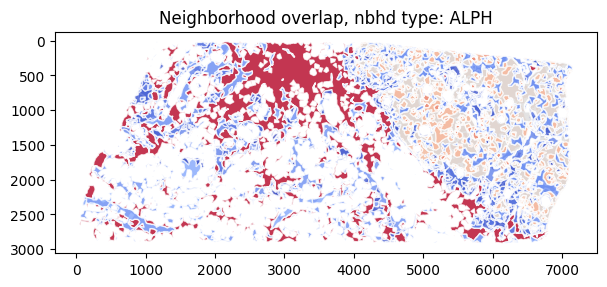

pivoted matrix


,0_35,10_35,1_35,2_35,3_35,4_35,5_35,6_35,7_35,8_35,9_35
0_35,NaN,12425.00,34152.73,4679966.74,86889.75,764157.63,297301.74,27883.91,637836.70,1026608.62,39657.38
10_35,12425.00,0.00,935449.19,31810.22,907615.12,0.00,755690.86,769024.86,58210.66,13642.15,3421.13
1_35,34152.73,935449.19,0.00,95054.43,3843267.53,0.00,2943534.21,3196554.21,283395.54,19837.35,34487.28
2_35,4679966.74,31810.22,95054.43,0.00,163217.27,240085.50,601852.44,107987.58,592361.43,1054802.86,19616.26
3_35,86889.75,907615.12,3843267.53,163217.27,0.00,0.00,2876013.72,2976043.83,448579.30,39194.98,52438.54
4_35,764157.63,0.00,0.00,240085.50,0.00,0.00,0.00,0.00,10221.88,27540.88,0.00
5_35,297301.74,755690.86,2943534.21,601852.44,2876013.72,0.00,0.00,2351732.16,423409.85,138812.96,34036.30
6_35,27883.91,769024.86,3196554.21,107987.58,2976043.83,0.00,2351732.16,0.00,192429.44,24778.17,17595.19
7_35,637836.70,58210.66,283395.54,592361.43,448579.30,10221.88,423409.85,192429.44,0.00,206143.71,12580.99
8_35,1026608.62,13642.15,19837.35,1054802.86,39194.98,27540.88,138812.96,24778.17,206143.71,0.00,14818.21


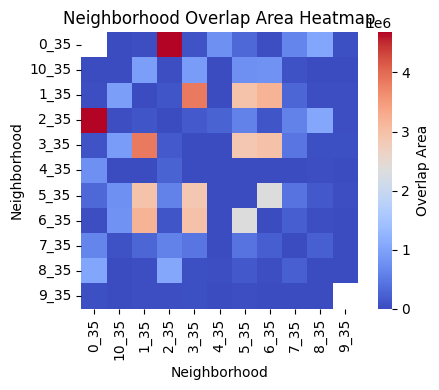

In [9]:

alphas_list = range(30, 60, 5)
df_cell = dega.nbhd._get_df_cell(adata_raw)
gdf_alpha = dega.nbhd.alpha_shape_cell_clusters(df_cell, cat='cluster', alphas=alphas_list)
gdf_nbhd = gdf_alpha.loc[gdf_alpha['inv_alpha']==35]

nb = gdf_nbhd[['name','geometry']]

print ('calculating neighborhood overlap')
df_nn = dega.nbhd.calc_nb_overlap(nb)
print (df_nn.shape)
display(df_nn.head(5))

if len(df_nn) > 0:
    fig, ax = plt.subplots(figsize=figsize)                           
    df_nn.plot('overlap_area', ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'Neighborhood overlap, nbhd type: ALPH')
    ax.invert_yaxis()
    plt.show()

    # Step 1: Pivot the data into a matrix
    df_matrix = df_nn.pivot(index="nbhd_1", columns="nbhd_2", values="overlap_area")

    # Step 2: Fill NaNs with 0 (no overlap) and make symmetric (optional but cleaner)
    df_matrix = df_matrix.fillna(0)
    df_matrix = df_matrix.add(df_matrix.T, fill_value=0)  # Symmetrize

    print ('pivoted matrix')
    display(df_matrix)

    # Step 3: Plot heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(df_matrix, cmap="coolwarm", annot=False, square=True, cbar_kws={'label': 'Overlap Area'})
    plt.title("Neighborhood Overlap Area Heatmap")
    plt.xlabel("Neighborhood")
    plt.ylabel("Neighborhood")
    plt.tight_layout()
    plt.show()
 


# Anndata and Mudata testing

In [10]:

def _to_adata(df):
    """Wrap a DataFrame as AnnData, ensuring .X is numeric and valid for saving."""
    obs = pd.DataFrame(index=df.index)
    X = df.drop(columns="geometry", errors="ignore").copy()
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)
    return AnnData(X=X, obs=obs)

munbhd = MuData({
    "NBG-CD": _to_adata(nbhd.get_derived("NBG-CD")),     # gene expression
    "NBG-CF": _to_adata(nbhd.get_derived("NBG-CF")),     # gene expression   
    "NBP": _to_adata(nbhd.get_derived("NBP", "abs")),    # population proportions
    "NBI": _to_adata(nbhd.get_derived("NBI"))  # image intensity
})

munbhd.write(f"{path_landscape_files}/nhbd_collections.h5mu")

meta = nbhd.get_derived('NBM')

### Use NBG-CD as example to create adata

In [11]:
# Select NB data type
nb_data_type = "NBG-CD"

# Load the h5mu file
mdata = mu.read(f"{path_landscape_files}/nhbd_collections.h5mu")
adata = mdata[nb_data_type]

# Get metadata
meta = nbhd.get_derived('NBM')

# Save geometry centroid to obsm['spatial']
dega.nbhd._add_centroids_to_obsm(adata, meta, key="spatial")

# Convert geo to coord list so that it can be saved in obs (obs does not support gdf)
d = meta.copy()
d["geometry"] = d.geometry.apply(_to_coords)
adata.obs = d

adata

AnnData object with n_obs × n_vars = 3065 × 378
    obs: 'nbhd_id', 'geometry', 'area_squm', 'perimeter_um', 'total_trx', 'unassigned_trx_count', 'assigned_trx_count', 'assigned_trx_pct', 'unassigned_trx_pct', 'cell_count'
    obsm: 'spatial'

In [12]:
adata.obs.head()

,nbhd_id,geometry,area_squm,perimeter_um,total_trx,unassigned_trx_count,assigned_trx_count,assigned_trx_pct,unassigned_trx_pct,cell_count
0,hex_0,"{'exterior': [[1047.7895131668147, 33.96585845...",6495.19,300.0,457.0,141.0,316.0,0.691466,0.308534,5.0
1,hex_1,"{'exterior': [[1134.3920535452585, 33.96585845...",6495.19,300.0,2176.0,518.0,1658.0,0.761949,0.238051,18.0
2,hex_2,"{'exterior': [[1220.9945939237023, 33.96585845...",6495.19,300.0,704.0,144.0,560.0,0.795455,0.204545,10.0
3,hex_3,"{'exterior': [[1307.5971343021463, 33.96585845...",6495.19,300.0,1212.0,273.0,939.0,0.774752,0.225248,9.0
4,hex_4,"{'exterior': [[1394.19967468059, 33.9658584594...",6495.19,300.0,429.0,246.0,183.0,0.426573,0.573427,7.0


In [13]:
adata.obsm['spatial'][:5]

array([[1004.48824298,    8.96585846],
       [1091.09078336,    8.96585846],
       [1177.69332373,    8.96585846],
       [1264.29586411,    8.96585846],
       [1350.89840449,    8.96585846]])

<Axes: title={'center': 'cell_count per nbhd'}, xlabel='cell_count', ylabel='Count'>

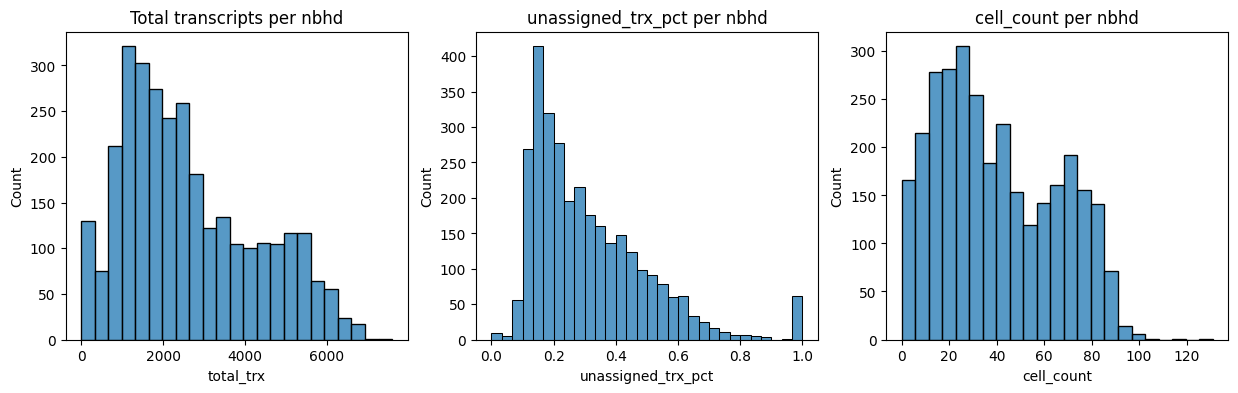

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].set_title("Total transcripts per nbhd")
sns.histplot(
    adata.obs["total_trx"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("unassigned_trx_pct per nbhd")
sns.histplot(
    adata.obs["unassigned_trx_pct"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("cell_count per nbhd")
sns.histplot(
    adata.obs["cell_count"],
    kde=False,
    ax=axs[2],
)


In [15]:
# Derived data
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


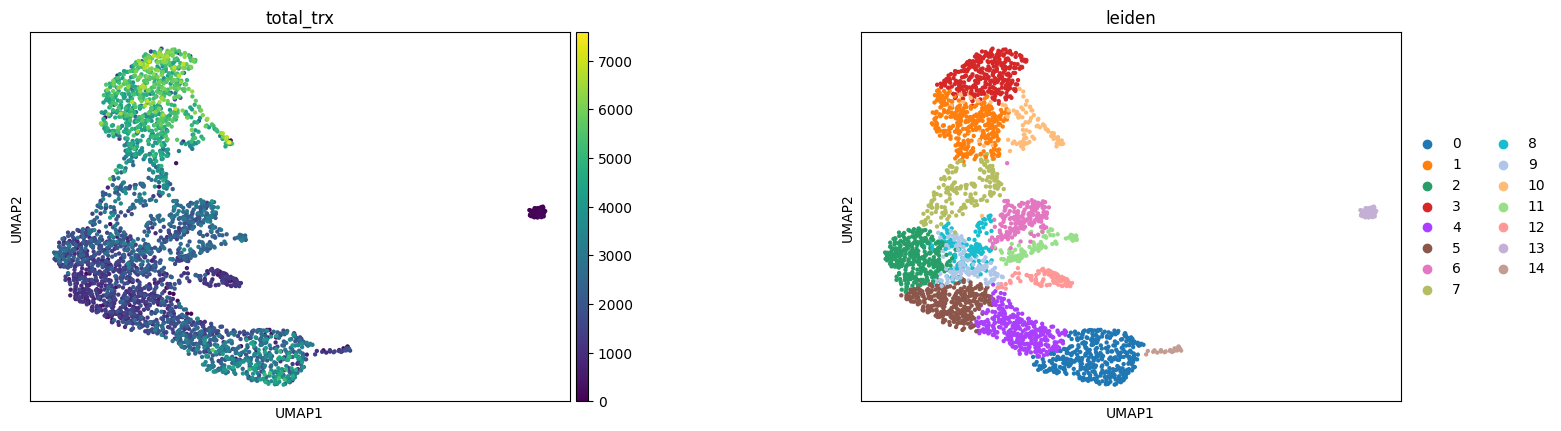

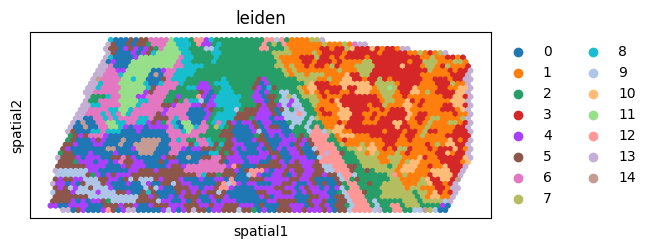

In [16]:
# Plotting 
sc.pl.umap(
    adata,
    color=[
        "total_trx",
        "leiden",
    ],
    wspace=0.4,
)

sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

### Build neighborhood graph

In [17]:
# Building a spatial neighborhood graph 
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

### Compute centrality score
Centrality scores are calculated with squidpy.gr.centrality_scores, with the Leiden groups as clusters.

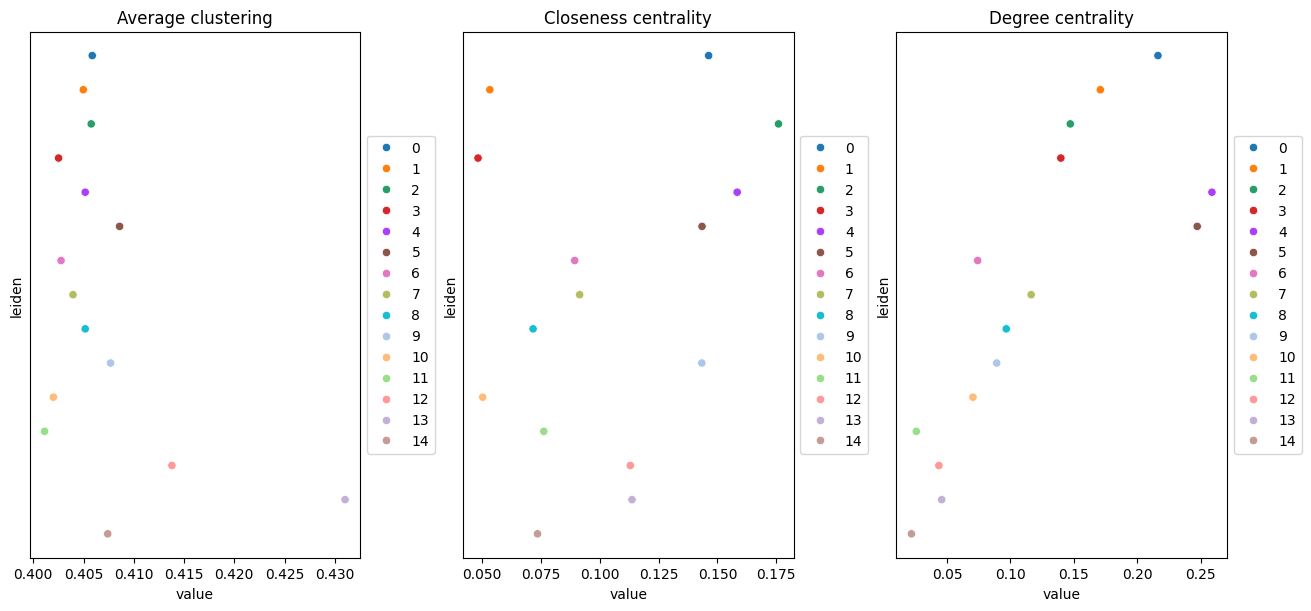

In [18]:
# Compute centrality scores
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(13, 6))

### Compute co-occurrence probability

  0%|          | 0/1 [00:00<?, ?/s]

/Users/whuan/miniconda3/envs/celldega_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/whuan/miniconda3/envs/celldega_env/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


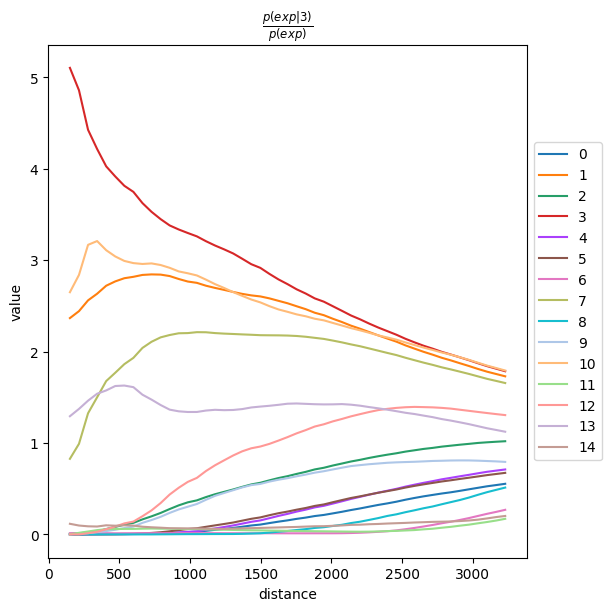

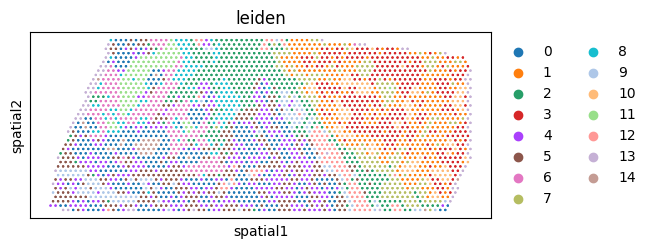

In [19]:
adata.obs['cell_id'] = adata.obs.index # Add a cell_id column using index


sq.gr.co_occurrence(
    adata,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata,
    cluster_key="leiden",
    clusters="3",
    figsize=(6, 6),
)
sq.pl.spatial_scatter(
    adata,
    color="leiden",
    shape=None,
    size=2,
)

### Neighbors enrichment analysis

  0%|          | 0/1000 [00:00<?, ?/s]

/Users/whuan/miniconda3/envs/celldega_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/whuan/miniconda3/envs/celldega_env/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


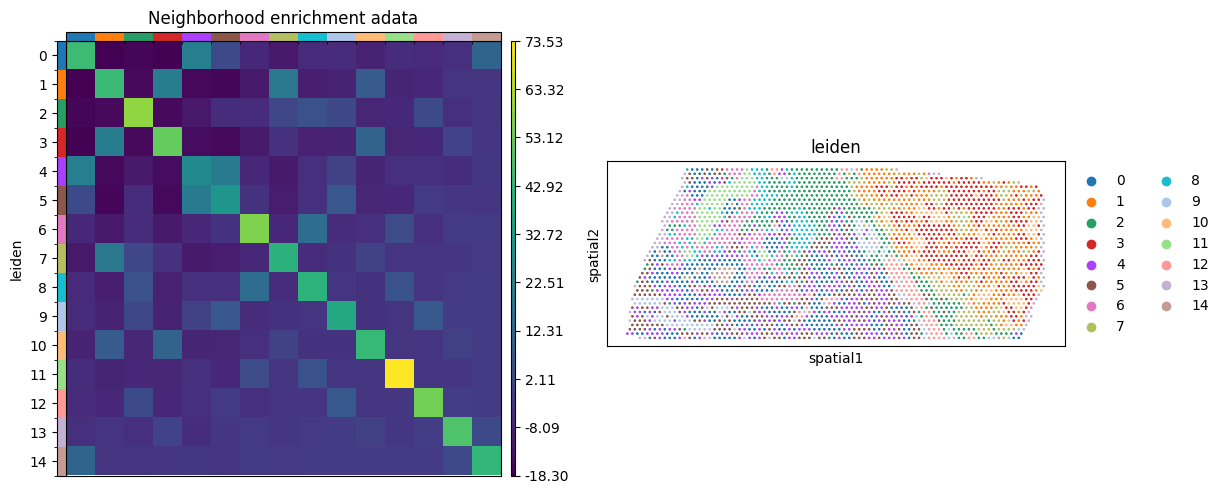

In [20]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(5,5),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata, color="leiden", shape=None, size=2, ax=ax[1])

In [21]:
adata

AnnData object with n_obs × n_vars = 3065 × 378
    obs: 'nbhd_id', 'geometry', 'area_squm', 'perimeter_um', 'total_trx', 'unassigned_trx_count', 'assigned_trx_count', 'assigned_trx_pct', 'unassigned_trx_pct', 'cell_count', 'leiden', 'cell_id'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'spatial_neighbors', 'leiden_centrality_scores', 'leiden_co_occurrence', 'leiden_nhood_enrichment'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'spatial_connectivities', 'spatial_distances'